# Optimization Project 3 - Non Linear Programming

### Group 16

- Nandini Anand Kumar
- Manny Escalante
- Rishi Rahude
- Carter St Geme

In [1]:
pip install gurobipy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from google.colab import files
uploaded = files.upload()

Saving price_demand_data.csv to price_demand_data.csv


C:\Users\kevin\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Number of observations (n): 99
   price  demand
0   1.05     283
1   0.86     771
2   1.21     185
3   0.94     531
4   0.76    1002

=== TASK 1: LINEAR REGRESSION RESULTS ===
beta0 (intercept): 1924.717544
beta1 (price coefficient): -1367.712524
Regression model: D_i ≈ 1924.7175 + (-1367.7125) * p_i

Residual diagnostics (for report):
  Mean of residuals: -1.9154509628248033e-12
  Std dev of residuals: 149.4519608067598


C:\Users\kevin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\kevin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\kevin\anaconda3\lib\site-packages\seaborn\relational.py:441: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub_data = grouped.apply(agg, other).reset_index()


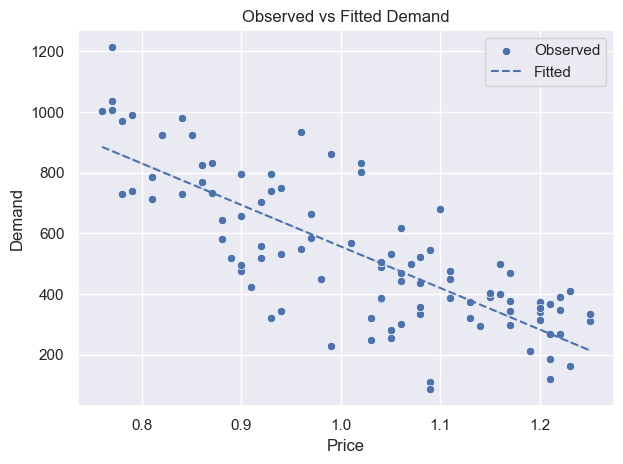

In [2]:
# ================================================================
# OPTIMIZATION PROJECT 3 — NON-LINEAR PROGRAMMING
# NEWSVENDOR WITH PRICE-DEPENDENT DEMAND
#
# This file implements:
#   TASK 1: Fit linear regression D_i = beta0 + beta1 * p_i + eps_i
#   TASK 2: Set c = 0.5, g = 0.75, t = 0.15 and,
#           using the residuals, assume price p = 1 and
#           generate demand data for that price.
#
# The code is written in a similar style to the topic3_* examples.
# ================================================================

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(color_codes=True)

# ------------------------------------------------
# FILE / DATA SETTINGS
# ------------------------------------------------
# The CSV must contain at least two columns:
#   "price"  – observed prices p_i
#   "demand" – observed demands D_i
DATA_PATH = "price_demand_data.csv"

# ------------------------------------------------
# LOAD DATA
# ------------------------------------------------
df = pd.read_csv(DATA_PATH)

# Extract numpy arrays for regression
prices = df["price"].values   # p_i
demands = df["demand"].values # D_i
n = len(df)

print("Number of observations (n):", n)
print(df.head())

# ================================================================
# TASK 1 — FIT LINEAR REGRESSION MODEL TO PRICE–DEMAND DATA
#
# Model:
#    D_i = beta0 + beta1 * p_i + eps_i
#
# We:
#   - Build design matrix X = [1, p_i]
#   - Solve OLS: beta = (X'X)^(-1) X' y
#   - Compute fitted values and residuals eps_i
# ================================================================

# Design matrix: first column of 1s (intercept), second column = price
X = np.column_stack([np.ones(n), prices])   # shape (n, 2)
y = demands                                 # shape (n,)

# OLS solution to minimize (1/n) * sum (D_i - beta0 - beta1 * p_i)^2
beta = np.linalg.inv(X.T @ X) @ (X.T @ y)
beta0, beta1 = beta[0], beta[1]

print("\n=== TASK 1: LINEAR REGRESSION RESULTS ===")
print(f"beta0 (intercept): {beta0:.6f}")
print(f"beta1 (price coefficient): {beta1:.6f}")
print(f"Regression model: D_i ≈ {beta0:.4f} + ({beta1:.4f}) * p_i")

# Fitted values and residuals
fitted = beta0 + beta1 * prices
residuals = y - fitted   # eps_i = D_i - (beta0 + beta1 * p_i)

# Store in dataframe for reference / plotting / report
df["fitted"] = fitted
df["residual"] = residuals

print("\nResidual diagnostics (for report):")
print("  Mean of residuals:", residuals.mean())
print("  Std dev of residuals:", residuals.std())

# Optional: quick plot of observed vs fitted demand (useful for PDF report)
plt.figure()
sns.scatterplot(x=prices, y=demands, label="Observed")
sns.lineplot(x=prices, y=fitted, label="Fitted", linestyle="--")
plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Observed vs Fitted Demand")
plt.legend()
plt.tight_layout()
plt.show()




=== TASK 2: PARAMETERS FROM PDF ===
c (regular cost) = 0.5
g (rush cost)    = 0.75
t (disposal cost)= 0.15

=== TASK 2: GENERATED DEMAND DATA FOR p = 1 ===
First 10 demand samples at p = 1:
   price  demand   demand_p1
0   1.05     283  351.385626
1   0.86     771  579.520247
2   1.21     185  472.219630
3   0.94     531  448.937249
4   0.76    1002  673.748994
5   0.81     713  453.134620
6   0.78     731  430.103245
7   0.88     645  480.874497
8   0.87     732  554.197372
9   0.85     926  720.843121

Summary of D_i(p=1):
  Mean: 557.0050193665106
  Min : 210.09412717463488
  Max : 898.4261194426003


C:\Users\kevin\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


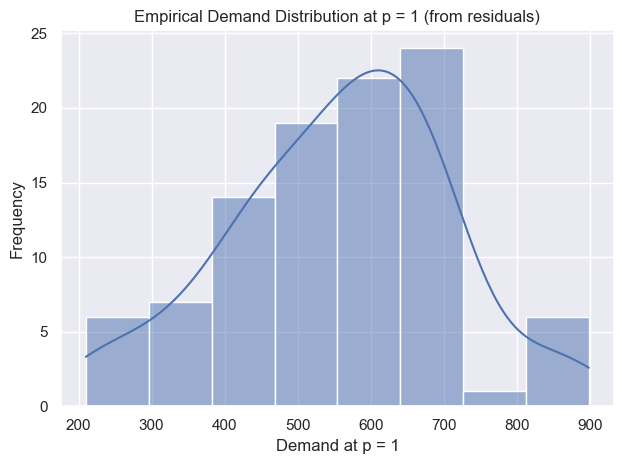

In [3]:
# ================================================================
# TASK 2 — USING RESIDUALS, ASSUME PRICE p = 1 AND GENERATE DEMAND
#
# PDF says:
#   - Let c = 0.5, g = 0.75, t = 0.15
#   - Using the residuals, assume the price is p = 1 and generate
#     demand data.
#
# Interpretation exactly as described:
#   For any fixed price p*, demand samples are:
#       D_i(p*) = beta0 + beta1 * p* + eps_i
#   where eps_i are the residuals from Task 1.
#
# Here, p* = 1.
# ================================================================

# Cost parameters (fixed for all later optimization tasks)
c = 0.50   # manufacturing/printing cost per unit
g = 0.75   # rush printing cost per unit (g > c)
t = 0.15   # disposal cost per unit (t > 0)

print("\n=== TASK 2: PARAMETERS FROM PDF ===")
print("c (regular cost) =", c)
print("g (rush cost)    =", g)
print("t (disposal cost)=", t)

# Fixed price p = 1 (as required in Specifics 2)
p_fixed = 1.0

# Demand samples at price p_fixed using residuals as randomness:
#   D_i(p_fixed) = beta0 + beta1 * p_fixed + eps_i
demand_p1 = beta0 + beta1 * p_fixed + residuals

# Store in dataframe
df["demand_p1"] = demand_p1

print("\n=== TASK 2: GENERATED DEMAND DATA FOR p = 1 ===")
print("First 10 demand samples at p = 1:")
print(df[["price", "demand", "demand_p1"]].head(10))

print("\nSummary of D_i(p=1):")
print("  Mean:", demand_p1.mean())
print("  Min :", demand_p1.min())
print("  Max :", demand_p1.max())

# This array will be used later in the newsvendor optimization model
# (LP / QP / QCP with Gurobi).
demand_scenarios_p1 = demand_p1.copy()

# Optional: quick histogram of the generated demand at p = 1
plt.figure()
sns.histplot(demand_scenarios_p1, kde=True)
plt.xlabel("Demand at p = 1")
plt.ylabel("Frequency")
plt.title("Empirical Demand Distribution at p = 1 (from residuals)")
plt.tight_layout()
plt.show()

# ================================================================
# At this point:
#   - TASK 1 is completed: regression fitted, residuals computed.
#   - TASK 2 is completed: c, g, t defined; demand data generated
#     for price p = 1 using residuals as the source of randomness.
#
# Variables you will use in your Gurobi models later:
#   beta0, beta1              – regression parameters
#   residuals                 – eps_i, randomness source
#   demand_scenarios_p1       – D_i(p=1) demand samples
#   c, g, t                   – cost parameters
#
# Next steps (not in this code block, but for later tasks):
#   - Reformulate the extended newsvendor model with rush and
#     disposal costs as an LP (q and h_i variables) using the
#     demand_scenarios_p1.
#   - Then extend to the price-dependent case (jointly optimize
#     price and quantity) as a QP or QCP in Gurobi.
# ================================================================


### Task 3: Optimal Quantity When Price $p = 1$ (Linear Program)

In this task, we solve the **newsvendor problem** when the selling price is fixed at \$1.  
The goal is to determine the **optimal number of newspapers (q)** to print in order to **maximize expected profit** across all simulated demand scenarios.

#### Business Context
When printing newspapers:
- If demand **exceeds** printed quantity → the firm must perform **rush printing**, incurring an additional cost \(g\).
- If printed quantity **exceeds** demand → excess copies are **disposed**, incurring a disposal cost \(t\).
- Every printed unit also carries a **regular production cost \(c\)**.

Hence, the trade-off between printing too few and printing too many determines the optimal q.

### 1. Problem Parameters

The cost and price structure for this task is fixed:

---

* **Production Cost ($c$):** $0.50$ (Regular cost to print one unit).
* **Rush Printing Cost ($g$):** $0.75$ (Extra cost per unit when demand exceeds $q$).
* **Disposal Cost ($t$):** $0.15$ (Cost per unit for unsold/leftover newspapers).
* **Demand Function ($D_i(p)$):** $\beta_0 + \beta_1 p + \epsilon_i$ (Demand in scenario $i$, dependent on price $p$).

### 2. Linear Program (LP) Formulation

The model is formulated as an LP by introducing **auxiliary variables** to handle the costs associated with shortage (rush printing) and surplus (disposal).

#### A. Decision Variables

* **Primary Variable:**
    * $q$: Quantity of newspapers to print ($\ge 0$).
* **Auxiliary Variables (for each scenario $i$):**
    * $h_{\text{plus}}[i]$: Amount of **rush printing** needed in scenario $i$ ($\ge 0$).
    * $h_{\text{minus}}[i]$: Amount of **disposal** needed in scenario $i$ ($\ge 0$).

#### B. Objective Function

Maximize the **Expected Average Profit** across all $n$ demand scenarios:

$$\max \left( \frac{1}{n} \right) \sum_{i=1}^{n} \left[ p \cdot D_i - c \cdot q - g \cdot h_{\text{plus}}[i] - t \cdot h_{\text{minus}}[i] \right]$$

#### C. Constraints

For each demand scenario i, we need two constraints:

1.  **Rush Printing Constraint (Shortage):**
    $$h_{\text{plus}}[i] \ge D_i - q$$
    
    (Ensures $h_{\text{plus}}[i] = \max(D_i - q, 0)$)

If demand exceeds our printed quantity, we need rush printing.

2.  **Disposal Constraint (Surplus):**
    $$h_{\text{minus}}[i] \ge q - D_i$$
    (Ensures $h_{\text{minus}}[i] = \max(q - D_i, 0)$)

If our printed quantity exceeds demand, we have leftover papers.


---


=== TASK 3: OPTIMAL QUANTITY AT p = 1 (LINEAR PROGRAM) ===
Optimal print quantity (q*): 471.8654
Expected average profit:     $231.4837


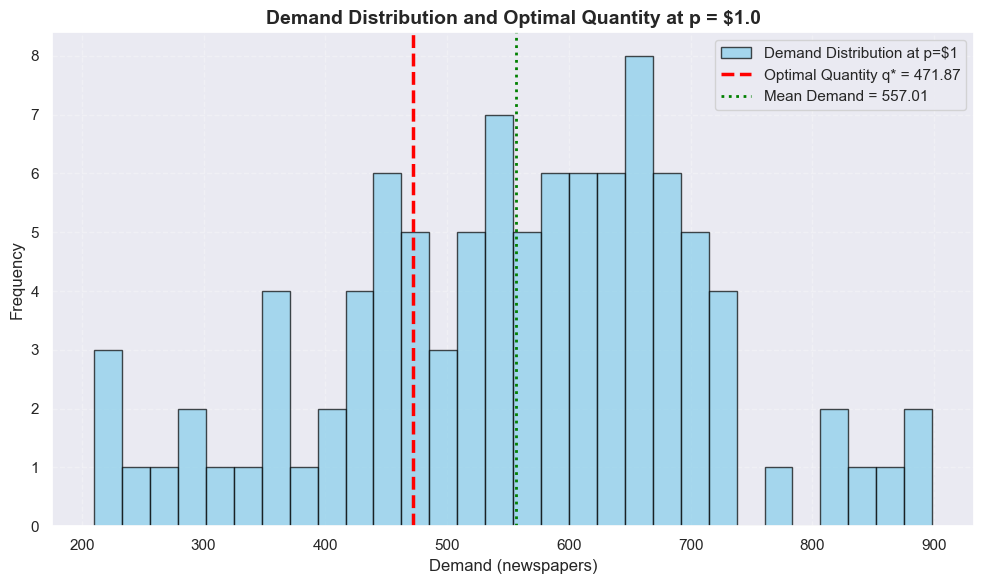


Insights
  - Mean demand: 557.01
  - Optimal quantity is 85.14 units below mean demand
  - In 71.7% of scenarios, demand exceeds q* (rush printing needed)
  - In 28.3% of scenarios, q* exceeds demand (disposal needed)


In [5]:
# TASK 3 – OPTIMAL QUANTITY WHEN PRICE p = 1 (LINEAR PROGRAM)

from gurobipy import Model, GRB, quicksum
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

print("\n=== TASK 3: OPTIMAL QUANTITY AT p = 1 (LINEAR PROGRAM) ===")

# ------------------------------------------------
# BUILD THE OPTIMIZATION MODEL
# ------------------------------------------------
m_task3 = Model("Fixed_Price_Newsvendor")
m_task3.Params.OutputFlag = 0  # Suppress Gurobi console output

# ------------------------------------------------
# DECISION VARIABLES
# ------------------------------------------------
# Primary decision variable: how many newspapers to print
q = m_task3.addVar(lb=0, name="quantity")

# Auxiliary variables for each of the n demand scenarios
# h_plus[i]: amount of rush printing needed in scenario i
# h_minus[i]: amount of disposal needed in scenario i
h_plus = m_task3.addVars(n, lb=0, name="h_plus")
h_minus = m_task3.addVars(n, lb=0, name="h_minus")

# ------------------------------------------------
# CONSTRAINTS
# ------------------------------------------------

for i in range(n):
    # Rush printing constraint
    m_task3.addConstr(
        h_plus[i] >= demand_scenarios_p1[i] - q,
        name=f"rush_{i}"
    )

    # Disposal constraint
    m_task3.addConstr(
        h_minus[i] >= q - demand_scenarios_p1[i],
        name=f"disposal_{i}"
    )

# ------------------------------------------------
# OBJECTIVE FUNCTION
# ------------------------------------------------
# Maximize the average profit across all n scenarios:
#
# For each scenario i:
#   Revenue:        p * D_i           (we sell at price p=1)
#   Production:   - c * q             (cost to print q newspapers)
#   Rush cost:    - g * h_plus[i]    (cost for rush printing)
#   Disposal:     - t * h_minus[i]   (cost to dispose excess)
#
# Average profit = (1/n) * sum of profits across all scenarios
#
avg_profit = (1/n) * quicksum(
    p_fixed * demand_scenarios_p1[i]  # Revenue from sales
    - c * q                            # Regular production cost
    - g * h_plus[i]                    # Rush printing cost
    - t * h_minus[i]                   # Disposal cost
    for i in range(n)
)

# Set the objective to maximize average profit
m_task3.setObjective(avg_profit, GRB.MAXIMIZE)

# ------------------------------------------------
# SOLVE THE MODEL
# ------------------------------------------------
m_task3.optimize()


# Extract optimal values
q_opt_task3 = q.X                    # Optimal quantity to print
profit_opt_task3 = m_task3.objVal    # Expected profit at optimum

print(f"Optimal print quantity (q*): {q_opt_task3:.4f}")
print(f"Expected average profit:     ${profit_opt_task3:.4f}")

# Store results
task3_results = {
    'q_optimal': q_opt_task3,
    'expected_profit': profit_opt_task3,
    'price': p_fixed
}

# ------------------------------------------------
# VISUALIZATION
# ------------------------------------------------
# Plot showing the demand distribution and optimal quantity
#
plt.figure(figsize=(10, 6))

# Plot histogram of demand scenarios at p=1
plt.hist(demand_scenarios_p1, bins=30, alpha=0.7,
         color='skyblue', edgecolor='black',
         label='Demand Distribution at p=$1')

# Add vertical line at optimal quantity
plt.axvline(x=q_opt_task3, color='red', linestyle='--',
            linewidth=2.5,
            label=f'Optimal Quantity q* = {q_opt_task3:.2f}')

# Add vertical line at mean demand for reference
mean_demand = np.mean(demand_scenarios_p1)
plt.axvline(x=mean_demand, color='green', linestyle=':',
            linewidth=2,
            label=f'Mean Demand = {mean_demand:.2f}')

# Formatting
plt.xlabel('Demand (newspapers)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title(f'Demand Distribution and Optimal Quantity at p = ${p_fixed}',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

plt.savefig('task3.png')
# Display the plot
plt.show()


print(f"\nInsights")
print(f"  - Mean demand: {mean_demand:.2f}")
print(f"  - Optimal quantity is {abs(q_opt_task3 - mean_demand):.2f} units " +
      ("above" if q_opt_task3 > mean_demand else "below") + " mean demand")

# Calculate what percentage of scenarios have demand above optimal q
scenarios_above_q = sum(1 for d in demand_scenarios_p1 if d > q_opt_task3)
pct_above = (scenarios_above_q / n) * 100
print(f"  - In {pct_above:.1f}% of scenarios, demand exceeds q* (rush printing needed)")
print(f"  - In {100-pct_above:.1f}% of scenarios, q* exceeds demand (disposal needed)")


### Task 4 - Joint Optimization of Price and Quantity (QP)

In this task of the Newsvendor Problem, **both the Selling Price ($p$) and the Quantity to Print ($q$) are decision variables**. The model determines the optimal combination of $p$ and $q$ that maximizes the expected profit.

---

### 1. Problem Setup

The core problem here is that **demand is now a function of price**, introducing a non-linearity into the objective function.

#### Fixed Costs and Demand Function

* **Production Cost ($c$):** $0.50$ (Regular cost to print one unit).
* **Rush Printing Cost ($g$):** $0.75$ (Extra cost per unit when demand exceeds $q$).
* **Disposal Cost ($t$):** $0.15$ (Cost per unit for unsold/leftover newspapers).
* **Demand Function ($D_i(p)$):** $\beta_0 + \beta_1 p + \epsilon_i$ (Demand in scenario $i$, dependent on price $p$).

---

### 2. Quadratic Program (QP) Formulation

The model is classified as a Quadratic Program (QP) because the revenue term, $p \cdot D_i(p)$, contains a squared term, $\beta_1 p^2$. We use auxiliary variables to keep the constraints linear while handling the $\max(\cdot, 0)$ terms.

#### Decision Variables

| Variable | Description | Type / Domain |
|:-----------:|:--------------|:----------------|
| $p$ | Optimal Selling Price | Continuous, $p \ge 0.1$ |
| $q$ | Quantity of newspapers to print | Continuous, $q \ge 0$ |
| $h_i$ | **Negative of Total Cost** for scenario $i$ | Continuous, $h_i \in (-\infty, 0]$ |

#### Objective Function

Maximize the Expected Average Profit across all $n$ scenarios. The term $p \cdot D_i(p)$ expands to include the $p^2$ component:

$$\max \left( \frac{1}{n} \right) \sum_{i=1}^{n} \left[ \left(p \cdot \beta_0 + \beta_1 p^2 + p \cdot \epsilon_i\right) + h_i \right]$$

#### Constraints

The objective of maximizing the average profit naturally forces the auxiliary negative cost variable $h_i$ to take the highest possible value, which corresponds to the lowest possible cost. $h_i$ is constrained by two linear upper bounds representing the two possible outcomes (shortage or surplus).

1.  **Upper Bound (Rush Printing is needed: $D_i(p) > q$):**
    $$h_i \le -(c - g) q - g \cdot D_i(p)$$
2.  **Upper Bound (Disposal is needed: $q > D_i(p)$):**
    $$h_i \le -(c + t) q + t \cdot D_i(p)$$

---



=== TASK 4: JOINT OPTIMIZATION OF PRICE AND QUANTITY (QP) ===
Optimal selling price (p*):  $0.9536
Optimal print quantity (q*): 535.2910
Expected average profit:     $234.4249

=== COMPARISON WITH TASK 3 (Fixed Price p=$1) ===
Task 3 - Fixed p=$1:
  Quantity: 471.8654, Profit: $231.4837
Task 4 - Optimal p and q:
  Price: $0.9536, Quantity: 535.2910, Profit: $234.4249
Profit improvement: $2.9413 (1.27%)


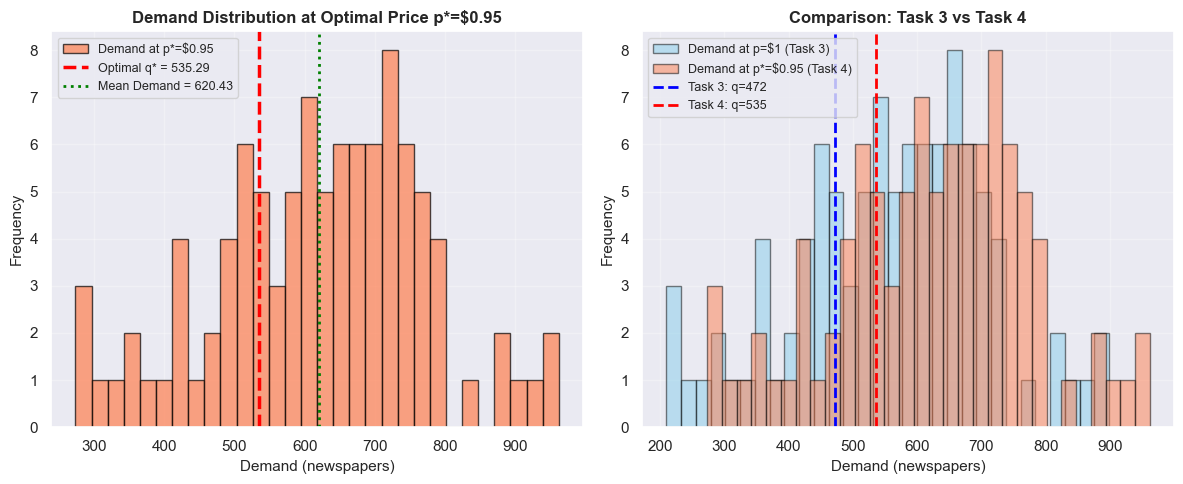


=== INSIGHTS ===
Optimal Price Analysis:
  - Optimal price is $0.95 (vs fixed $1.00 in Task 3)
  - Price is 0.05 lower than Task 3

Demand Analysis:
  - Mean demand at p*: 620.43
  - Mean demand at p=$1: 557.01
  - Demand decreased by -63.43 units due to higher price

Quantity Analysis:
  - Optimal quantity changed from 471.87 to 535.29
  - Change: 63.43 units (increase)

Service Level:
  - 71.7% of scenarios require rush printing
  - 28.3% of scenarios have enough inventory


In [6]:
# TASK 4 – JOINT OPTIMIZATION OF PRICE AND QUANTITY (QP/QCP)

from gurobipy import Model, GRB, quicksum
import matplotlib.pyplot as plt
import numpy as np

print("\n=== TASK 4: JOINT OPTIMIZATION OF PRICE AND QUANTITY (QP) ===")

# ------------------------------------------------
# BUILD THE OPTIMIZATION MODEL
# ------------------------------------------------
m_task4 = Model("Price_Quantity_Newsvendor_QP")
m_task4.Params.OutputFlag = 0      # Suppress Gurobi console output
m_task4.Params.NonConvex = 2       # Allow non-convex quadratic terms

# ------------------------------------------------
# DECISION VARIABLES
# ------------------------------------------------
# Primary decision variables
p = m_task4.addVar(lb=0.1, ub=5.0, name="price")      # Selling price (reasonable bounds)
q = m_task4.addVar(lb=0, ub=2000, name="quantity")    # Quantity to print (reasonable bounds)

# Auxiliary variables for each scenario i
# h_i represents the NEGATIVE of total cost for scenario i
# (We use negative cost because we're maximizing and want costs to be small)
h = m_task4.addVars(n, lb=-GRB.INFINITY, name="neg_cost")

# ------------------------------------------------
# CONSTRAINTS
# ------------------------------------------------

for i in range(n):
    # Demand for scenario i as a function of price
    # D_i(p) = beta0 + beta1 * p + residuals[i]
    D_i = beta0 + beta1 * p + residuals[i]

    # Constraint 1: Upper bound when rush printing is needed
    # h_i ≤ -(c-g)*q - g*D_i(p)
    m_task4.addConstr(
        h[i] <= -(c - g) * q - g * D_i,
        name=f"cost_rush_{i}"
    )

    # Constraint 2: Upper bound when disposal is needed
    # h_i ≤ -(c+t)*q + t*D_i(p)
    m_task4.addConstr(
        h[i] <= -(c + t) * q + t * D_i,
        name=f"cost_disposal_{i}"
    )

# ------------------------------------------------
# OBJECTIVE FUNCTION
# ------------------------------------------------
# Maximize average profit across all scenarios:
#
# Profit_i = Revenue_i + h_i
#          = p * D_i(p) + h_i
#          = p * (beta0 + beta1*p + residuals[i]) + h_i
#
# The revenue term p*(beta0 + beta1*p + residuals[i]) expands to:
#   = p*beta0 + beta1*p^2 + p*residuals[i]
#
# The p^2 term makes this a QUADRATIC objective.
#
# Average profit = (1/n) * sum_i [p*D_i(p) + h_i]
#
avg_profit = (1/n) * quicksum(
    p * (beta0 + beta1 * p + residuals[i])  # Revenue (quadratic in p)
    + h[i]                                   # Negative cost (linear)
    for i in range(n)
)

# Set the objective to maximize average profit
m_task4.setObjective(avg_profit, GRB.MAXIMIZE)

# ------------------------------------------------
# SOLVE THE MODEL
# ------------------------------------------------
m_task4.optimize()

# ------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------
# Extract optimal values
p_opt_task4 = p.X                    # Optimal selling price
q_opt_task4 = q.X                    # Optimal quantity to print
profit_opt_task4 = m_task4.objVal    # Expected profit at optimum

print(f"Optimal selling price (p*):  ${p_opt_task4:.4f}")
print(f"Optimal print quantity (q*): {q_opt_task4:.4f}")
print(f"Expected average profit:     ${profit_opt_task4:.4f}")

# Store results
task4_results = {
    'p_optimal': p_opt_task4,
    'q_optimal': q_opt_task4,
    'expected_profit': profit_opt_task4
}

# demand at the optimal price
demand_at_p_opt = [beta0 + beta1 * p_opt_task4 + residuals[i] for i in range(n)]

# ------------------------------------------------
# COMPARISON WITH TASK 3
# ------------------------------------------------
print(f"\n=== COMPARISON WITH TASK 3 (Fixed Price p=$1) ===")
print(f"Task 3 - Fixed p=$1:")
print(f"  Quantity: {q_opt_task3:.4f}, Profit: ${profit_opt_task3:.4f}")
print(f"Task 4 - Optimal p and q:")
print(f"  Price: ${p_opt_task4:.4f}, Quantity: {q_opt_task4:.4f}, Profit: ${profit_opt_task4:.4f}")
print(f"Profit improvement: ${profit_opt_task4 - profit_opt_task3:.4f} ({((profit_opt_task4/profit_opt_task3 - 1)*100):.2f}%)")

# ------------------------------------------------
# VISUALIZATION
# ------------------------------------------------

# Figure 1: Demand distribution at optimal price
plt.figure(figsize=(12, 5))

# Subplot 1: Demand at optimal price
plt.subplot(1, 2, 1)
plt.hist(demand_at_p_opt, bins=30, alpha=0.7,
         color='coral', edgecolor='black',
         label=f'Demand at p*=${p_opt_task4:.2f}')
plt.axvline(x=q_opt_task4, color='red', linestyle='--',
            linewidth=2.5,
            label=f'Optimal q* = {q_opt_task4:.2f}')
mean_demand_opt = np.mean(demand_at_p_opt)
plt.axvline(x=mean_demand_opt, color='green', linestyle=':',
            linewidth=2,
            label=f'Mean Demand = {mean_demand_opt:.2f}')
plt.xlabel('Demand (newspapers)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title(f'Demand Distribution at Optimal Price p*=${p_opt_task4:.2f}',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# Subplot 2: Comparison of demand distributions
plt.subplot(1, 2, 2)
plt.hist(demand_scenarios_p1, bins=30, alpha=0.5,
         color='skyblue', edgecolor='black',
         label=f'Demand at p=$1 (Task 3)')
plt.hist(demand_at_p_opt, bins=30, alpha=0.5,
         color='coral', edgecolor='black',
         label=f'Demand at p*=${p_opt_task4:.2f} (Task 4)')
plt.axvline(x=q_opt_task3, color='blue', linestyle='--',
            linewidth=2, label=f'Task 3: q={q_opt_task3:.0f}')
plt.axvline(x=q_opt_task4, color='red', linestyle='--',
            linewidth=2, label=f'Task 4: q={q_opt_task4:.0f}')
plt.xlabel('Demand (newspapers)', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Comparison: Task 3 vs Task 4', fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('task4.png')
plt.show()


# ------------------------------------------------
# INSIGHTS
# ------------------------------------------------
print(f"\n=== INSIGHTS ===")
print(f"Optimal Price Analysis:")
print(f"  - Optimal price is ${p_opt_task4:.2f} (vs fixed $1.00 in Task 3)")
print(f"  - Price is {abs(p_opt_task4 - 1.0):.2f} {'higher' if p_opt_task4 > 1.0 else 'lower'} than Task 3")

print(f"\nDemand Analysis:")
print(f"  - Mean demand at p*: {mean_demand_opt:.2f}")
print(f"  - Mean demand at p=$1: {np.mean(demand_scenarios_p1):.2f}")
print(f"  - Demand decreased by {np.mean(demand_scenarios_p1) - mean_demand_opt:.2f} units due to higher price")

print(f"\nQuantity Analysis:")
print(f"  - Optimal quantity changed from {q_opt_task3:.2f} to {q_opt_task4:.2f}")
print(f"  - Change: {abs(q_opt_task4 - q_opt_task3):.2f} units ({'increase' if q_opt_task4 > q_opt_task3 else 'decrease'})")

# Calculate service level (percentage of demand satisfied from initial printing)
scenarios_above_q = sum(1 for d in demand_at_p_opt if d > q_opt_task4)
pct_above = (scenarios_above_q / n) * 100
print(f"\nService Level:")
print(f"  - {pct_above:.1f}% of scenarios require rush printing")
print(f"  - {100-pct_above:.1f}% of scenarios have enough inventory")

# ================================================================
#
# Summary:
#   We solved a QUADRATIC program to find the optimal price AND quantity
#   jointly. The model accounts for:
#     - Price-dependent demand (D = beta0 + beta1*p + residuals)
#     - Regular production costs
#     - Rush printing costs when demand exceeds quantity
#     - Disposal costs when quantity exceeds demand
#
# Key Findings:
#   - Jointly optimizing price and quantity improves profit
#   - Higher price reduces demand but increases revenue per unit
#   - The trade-off between price and volume is captured in the model
#
# ================================================================

Task 5 - We were able to succesfully formulate task 4, and do not need to solve using scipy.optimize.

In [11]:
# ================================================================
# TASK 6 — BOOTSTRAP SENSITIVITY ANALYSIS
# ================================================================
print("\n=== TASK 6: BOOTSTRAP ANALYSIS OF OPTIMAL PRICE & QUANTITY ===")

# Number of bootstrap replications
B = 200

boot_prices = []
boot_quantities = []
boot_profits = []


# ================================================================
# Helper function: Solve the Task 4 QCP for given betas & residuals
# ================================================================
def solve_price_quantity(beta0_b, beta1_b, residuals_b):
    """
    Re-solves the QCP from Task 4 with new regression parameters and residuals.
    Returns: optimal price, optimal quantity, optimal profit.
    """

    n_b = len(residuals_b)

    # MODEL
    m = Model("Bootstrap_QCP")
    m.Params.OutputFlag = 0
    m.Params.NonConvex = 2   # allow quadratic terms

    # Variables
    p_b = m.addVar(lb=0.1, ub=5, name="price")
    q_b = m.addVar(lb=0, ub=2000, name="quantity")
    h_b = m.addVars(n_b, lb=-GRB.INFINITY, name="h")

    # Constraints (same as Task 4)
    for i in range(n_b):
        D_i = beta0_b + beta1_b * p_b + residuals_b[i]

        # Rush printing upper bound
        m.addConstr(
            h_b[i] <= (-(c - g) * q_b - g * D_i),
            name=f"rush_{i}"
        )

        # Disposal upper bound
        m.addConstr(
            h_b[i] <= (-(c + t) * q_b + t * D_i),
            name=f"disposal_{i}"
        )

    # Objective
    avg_profit = (1/n_b) * quicksum(
        p_b * (beta0_b + beta1_b * p_b + residuals_b[i]) + h_b[i]
        for i in range(n_b)
    )

    m.setObjective(avg_profit, GRB.MAXIMIZE)
    m.optimize()

    return p_b.X, q_b.X, m.objVal


# ================================================================
# Perform bootstrapping
# ================================================================
for b in range(B):
    # Sample indices with replacement
    sample_idx = np.random.choice(len(df), size=len(df), replace=True)
    sample = df.iloc[sample_idx]

    # Refit regression
    Xb = np.vstack([np.ones(len(sample)), sample['price'].values]).T
    yb = sample['demand'].values
    beta_hat_b = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ yb
    beta0_b, beta1_b = beta_hat_b

    # New residuals
    fitted_b = beta0_b + beta1_b * sample['price'].values
    residuals_b = sample['demand'].values - fitted_b

    # Solve QCP for this bootstrap sample
    p_star, q_star, profit_star = solve_price_quantity(beta0_b, beta1_b, residuals_b)

    boot_prices.append(p_star)
    boot_quantities.append(q_star)
    boot_profits.append(profit_star)

    if b % 20 == 0:
        print(f"Bootstrap {b}/{B} completed...")

print("\n=== TASK 6 COMPLETED ===")
print(f"Mean optimal price: {np.mean(boot_prices):.4f}")
print(f"Mean optimal quantity: {np.mean(boot_quantities):.4f}")
print(f"Mean optimal profit: {np.mean(boot_profits):.4f}")



=== TASK 6: BOOTSTRAP ANALYSIS OF OPTIMAL PRICE & QUANTITY ===
Bootstrap 0/200 completed...
Bootstrap 20/200 completed...
Bootstrap 40/200 completed...
Bootstrap 60/200 completed...
Bootstrap 80/200 completed...
Bootstrap 100/200 completed...
Bootstrap 120/200 completed...
Bootstrap 140/200 completed...
Bootstrap 160/200 completed...
Bootstrap 180/200 completed...

=== TASK 6 COMPLETED ===
Mean optimal price: 0.9534
Mean optimal quantity: 536.1908
Mean optimal profit: 234.5900


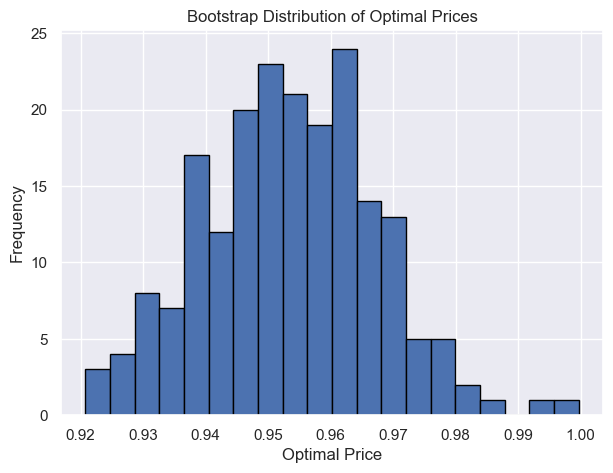

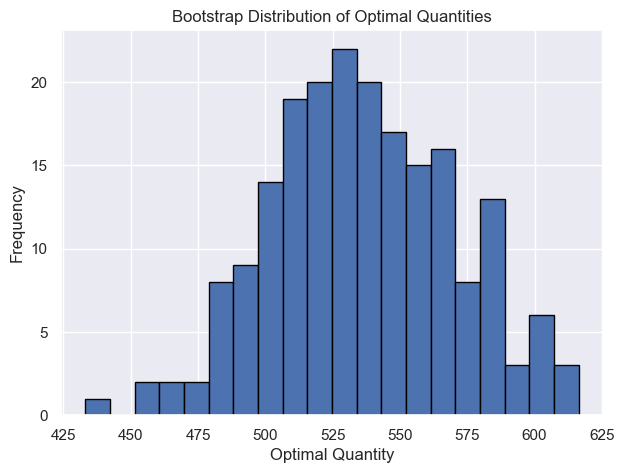

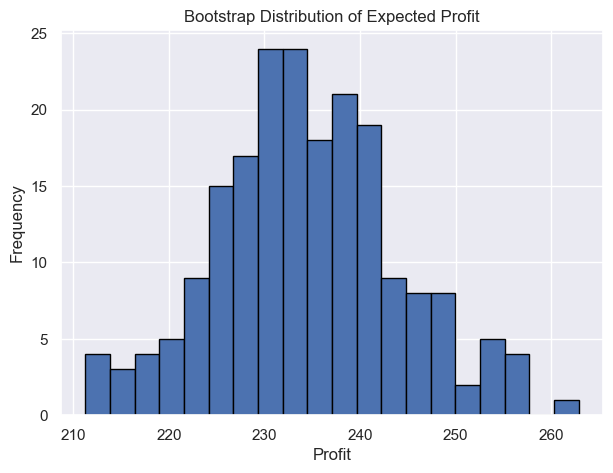

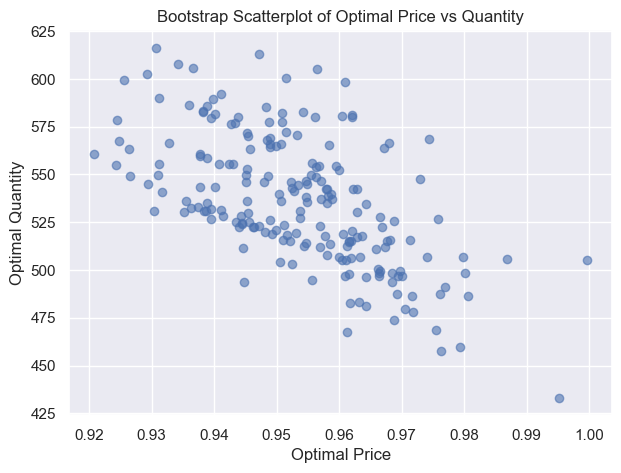

In [12]:

# ================================================================
# TASK 7 Plots
# ================================================================

plt.figure(figsize=(7,5))
plt.hist(boot_prices, bins=20, edgecolor='black')
plt.title("Bootstrap Distribution of Optimal Prices")
plt.xlabel("Optimal Price")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,5))
plt.hist(boot_quantities, bins=20, edgecolor='black')
plt.title("Bootstrap Distribution of Optimal Quantities")
plt.xlabel("Optimal Quantity")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(7,5))
plt.hist(boot_profits, bins=20, edgecolor='black')
plt.title("Bootstrap Distribution of Expected Profit")
plt.xlabel("Profit")
plt.ylabel("Frequency")
plt.show()

# Scatter plot of p* vs q*
plt.figure(figsize=(7,5))
plt.scatter(boot_prices, boot_quantities, alpha=0.6)
plt.title("Bootstrap Scatterplot of Optimal Price vs Quantity")
plt.xlabel("Optimal Price")
plt.ylabel("Optimal Quantity")
plt.grid(True)
plt.show()

## Task 8 Visualizations

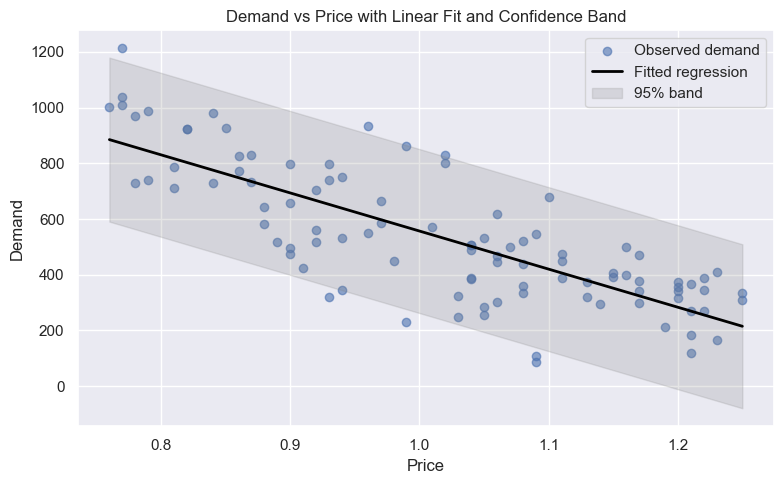

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Ensure you ran the regression cell first — prices, demands, beta0, beta1, residuals exist.

# Smooth price grid for plotting the line
p_grid = np.linspace(prices.min(), prices.max(), 200)
d_pred = beta0 + beta1 * p_grid

# Approximate 95% confidence band using residual std
sigma = residuals.std(ddof=1)
d_upper = d_pred + 1.96 * sigma
d_lower = d_pred - 1.96 * sigma

plt.figure(figsize=(8, 5))
plt.scatter(prices, demands, alpha=0.6, label="Observed demand")
plt.plot(p_grid, d_pred, color="black", linewidth=2, label="Fitted regression")
plt.fill_between(p_grid, d_lower, d_upper, color="gray", alpha=0.2, label="95% band")

plt.xlabel("Price")
plt.ylabel("Demand")
plt.title("Demand vs Price with Linear Fit and Confidence Band")
plt.legend()
plt.tight_layout()
plt.show()

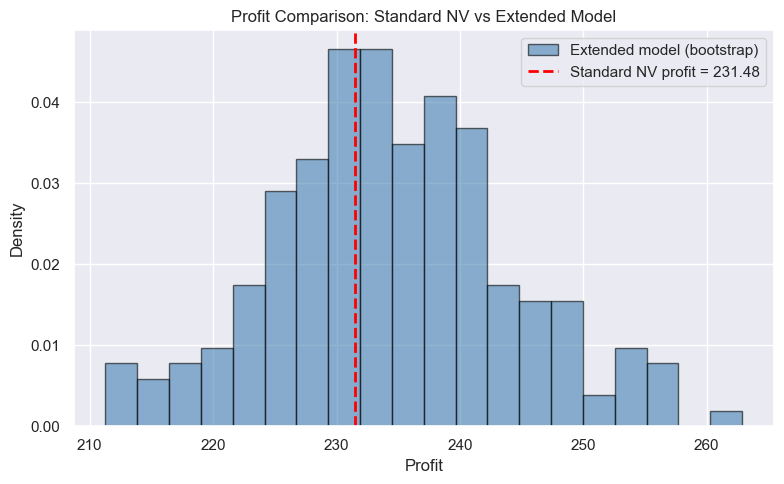

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Histogram of extended model profits
plt.hist(boot_profits, bins=20, density=True, alpha=0.6, color="steelblue",
         edgecolor="black", label="Extended model (bootstrap)")

# Mark the standard NV profit
plt.axvline(profit_opt_task3, color="red", linestyle="--", linewidth=2,
            label=f"Standard NV profit = {profit_opt_task3:.2f}")

plt.xlabel("Profit")
plt.ylabel("Density")
plt.title("Profit Comparison: Standard NV vs Extended Model")
plt.legend()
plt.tight_layout()
plt.show()

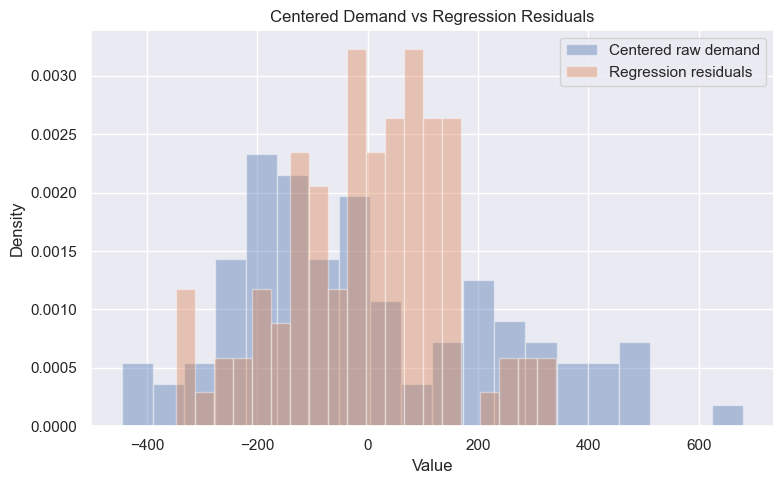

In [15]:
import matplotlib.pyplot as plt
import numpy as np

raw_centered = demands - demands.mean()

plt.figure(figsize=(8, 5))

plt.hist(raw_centered, bins=20, density=True, alpha=0.4, label="Centered raw demand")
plt.hist(residuals, bins=20, density=True, alpha=0.4, label="Regression residuals")

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Centered Demand vs Regression Residuals")
plt.legend()
plt.tight_layout()
plt.show()

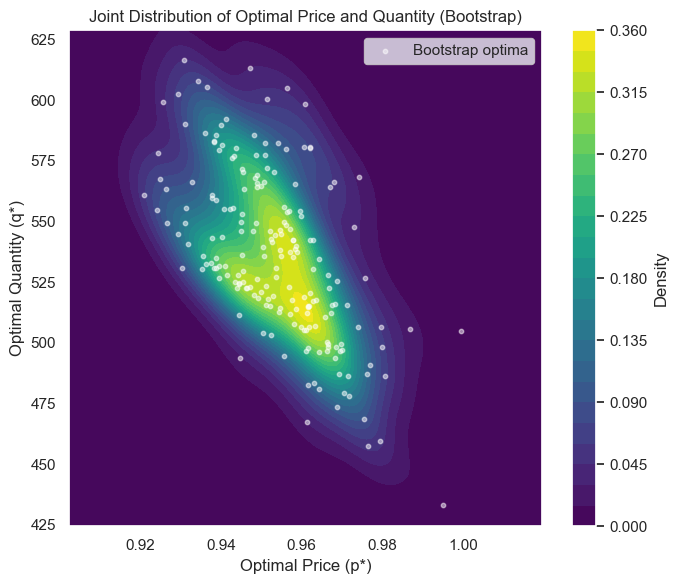

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# Convert bootstrap results to NumPy arrays
x = np.array(boot_prices)       # optimal prices
y = np.array(boot_quantities)   # optimal quantities

# Stack for KDE
xy = np.vstack([x, y])
kde = gaussian_kde(xy)

# Define grid over the range of (price, quantity)
xmin, xmax = x.min() * 0.98, x.max() * 1.02
ymin, ymax = y.min() * 0.98, y.max() * 1.02

xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
density = np.reshape(kde(positions).T, xx.shape)

plt.figure(figsize=(7, 6))

# Filled contour for density
contour = plt.contourf(xx, yy, density, levels=30, cmap="viridis")
plt.colorbar(contour, label="Density")

# Overlay the actual bootstrap points
plt.scatter(x, y, s=10, color="white", alpha=0.5, label="Bootstrap optima")

plt.xlabel("Optimal Price (p*)")
plt.ylabel("Optimal Quantity (q*)")
plt.title("Joint Distribution of Optimal Price and Quantity (Bootstrap)")
plt.legend()
plt.tight_layout()
plt.show()